In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Load the Spotify songs dataset
df = pd.read_csv('spotify_songs.csv')

#Clean
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_', regex=False)
    .str.replace('-', '_', regex=False)
)

#remove duplicate rows
df = df.drop_duplicates()

#easier reading
df['streams_millions'] = df['streams'] / 1000000

df.head()


,song,artist,genre,year,streams,in_spotify_playlists,on_spotify_charts,billboard_rankings,in_apple_playlists,on_apple_charts,...,mode,energy,danceability,liveness,valence,duration,acousticness,speechiness,popularity,streams_millions
0,3,Britney Spears,Dance Pop,2010,339473453,2612,258,192,32497,69,...,Major,71,70,14,79,213,5,5,62,339.473453
1,24K Magic,Bruno Mars,Pop,2017,496311364,3983,421,12,31539,12,...,Major,80,82,15,63,226,3,8,85,496.311364
2,A Thousand Years,Christina Perri,Dance Pop,2011,1690192927,21097,21,442,20617,78,...,Minor,41,42,11,16,285,31,3,81,1690.192927
3,Adore You,Miley Cyrus,Dance Pop,2014,672656250,5481,308,3,18752,3,...,Major,66,58,11,20,279,11,3,72,672.656250
4,Ain't Your Mama,Jennifer Lopez,Dance Pop,2016,652704649,5328,180,73,17392,73,...,Minor,68,76,7,82,218,5,23,72,652.704649


Problem Space

Music streaming has changed the way songs become popular and how success is measured in the music industry. Instead of only looking at album sales or radio play, Spotify-style data allows us to study streams, playlists, chart placement, and audio features such as danceability, energy, valence, acousticness, and speechiness.

My analysis seeks to determine patterns in Spotify song success by addressing the following questions:
1. Which songs have the most Spotify streams?
2. Which artists have the highest total streams?
3. Which genres have the highest average popularity?
4. How do streams change by year?
5. Is playlist placement related to streams?
6. Do audio features like danceability and energy help explain popularity?


Questions to Explore

As mentioned previously, the following questions will guide my analysis:
1. Which songs have the most Spotify streams?
2. Which artists have the highest total streams?
3. Which genres have the highest average popularity?
4. How do streams change by year?
5. Does being placed in more Spotify playlists relate to having more streams?
6. How do danceability and energy relate to popularity?


,song,artist,year,streams_millions,popularity
10,All of Me,John Legend,2014,2420.461338,86
35,Closer,The Chainsmokers,2017,2355.719893,86
19,Beautiful People,Ed Sheeran,2019,2303.033973,86
14,Attention,Charlie Puth,2018,1791.000570,83
8,All Around The World (La La La),R3HAB,2019,1692.897992,82
2,A Thousand Years,Christina Perri,2011,1690.192927,81
29,Cake By The Ocean,DNCE,2016,1608.164312,81
31,Call You Mine,The Chainsmokers,2019,1575.467011,81
18,Bad Romance,Lady Gaga,2010,1406.111294,79
32,Cant Stop The Feeling,Justin Timberlake,2016,1304.313953,79


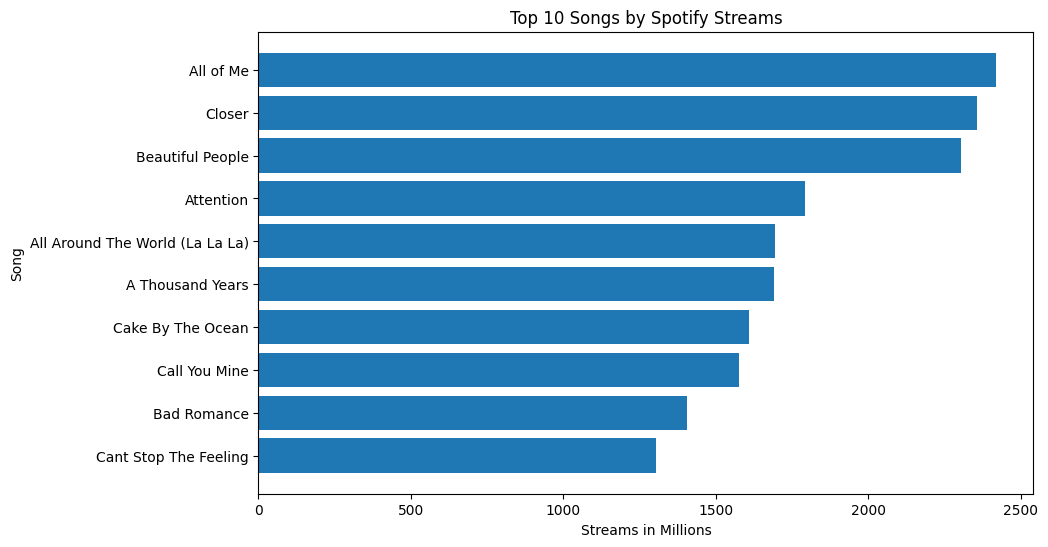

In [3]:
#Analyzing the Top Songs by Spotify Streams
#Using Pandas to sort the dataset by streams in millions
top_songs = (
    df[['song', 'artist', 'year', 'streams_millions', 'popularity']]
    .sort_values('streams_millions', ascending=False)
    .head(10)
)

#Display the Pandas table
display(top_songs)

#Create a bar chart of the top streamed songs
plt.figure(figsize=(10,6))
plt.barh(top_songs['song'], top_songs['streams_millions'])
plt.gca().invert_yaxis()
plt.title('Top 10 Songs by Spotify Streams')
plt.xlabel('Streams in Millions')
plt.ylabel('Song')
plt.show()


Analysis of the Top Songs by Spotify Streams

The chart shows which songs had the highest number of streams in the dataset. Songs such as *All of Me*, *Closer*, and *Beautiful People* appear near the top, showing that highly streamed songs can come from different years and artists. This suggests that Spotify success is not only about being a newer song, but also about replay value, artist recognition, and long-term popularity.


,artist,total_streams_millions,song_count,avg_popularity
30,The Chainsmokers,3931.186904,2,83.500000
10,Ed Sheeran,3448.761584,2,82.000000
18,Lady Gaga,2693.864780,3,73.666667
14,Justin Bieber,2433.565001,3,73.333333
13,John Legend,2420.461338,1,86.000000
1,Ariana Grande,2061.207841,2,76.500000
7,Charlie Puth,1791.000570,1,83.000000
16,Katy Perry,1696.443324,2,73.000000
25,R3HAB,1692.897992,1,82.000000
8,Christina Perri,1690.192927,1,81.000000


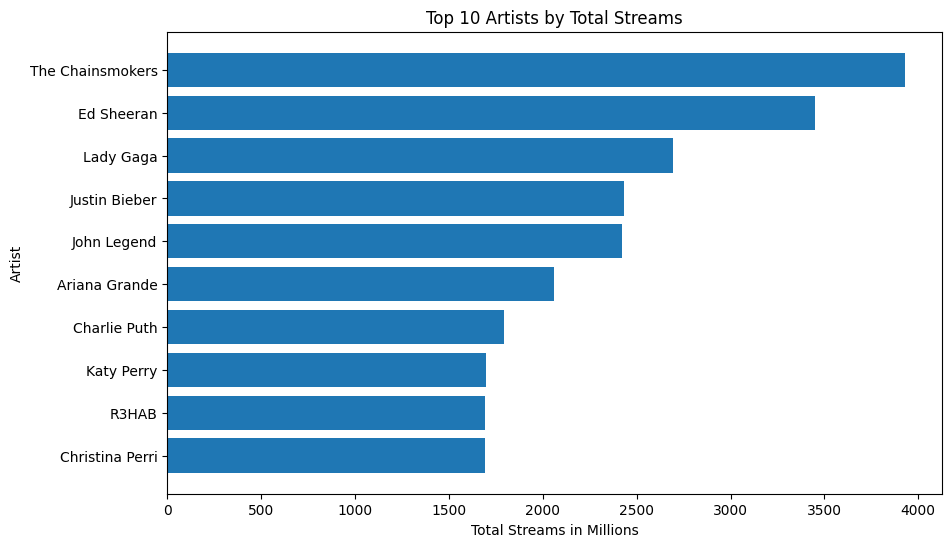

In [4]:
#Analyzing Total Streams by Artist
#Using groupby to combine all songs for each artist
top_artists = (
    df.groupby('artist', as_index=False)
    .agg(
        total_streams_millions=('streams_millions', 'sum'),
        song_count=('song', 'count'),
        avg_popularity=('popularity', 'mean')
    )
    .sort_values('total_streams_millions', ascending=False)
    .head(10)
)

#Display the Pandas table
display(top_artists)

#Create a bar chart of artists by total streams
plt.figure(figsize=(10,6))
plt.barh(top_artists['artist'], top_artists['total_streams_millions'])
plt.gca().invert_yaxis()
plt.title('Top 10 Artists by Total Streams')
plt.xlabel('Total Streams in Millions')
plt.ylabel('Artist')
plt.show()


Analysis of the Correlation Between Artist and Streams

The graph shows that artists with multiple popular songs have an advantage because their total streams add across their catalog. This makes artist presence important when studying music streaming data. The results suggest that Spotify success is partly connected to the strength of the artist's overall catalog, not just one individual song.


,genre,avg_popularity,avg_streams_millions,song_count
9,Neo Mellow,86.000000,2420.461338,1
7,Electropop,83.500000,1965.593452,2
2,Big Room,82.000000,1692.897992,1
10,Pop,80.800000,1088.518500,5
8,Latin,76.000000,939.844851,1
6,Dance Pop,74.285714,955.837081,21
5,Canadian Pop,74.000000,858.328320,4
3,Boy Band,73.000000,725.980112,1
4,British Soul,71.000000,594.482982,1
1,Barbadian Pop,61.000000,323.437194,1


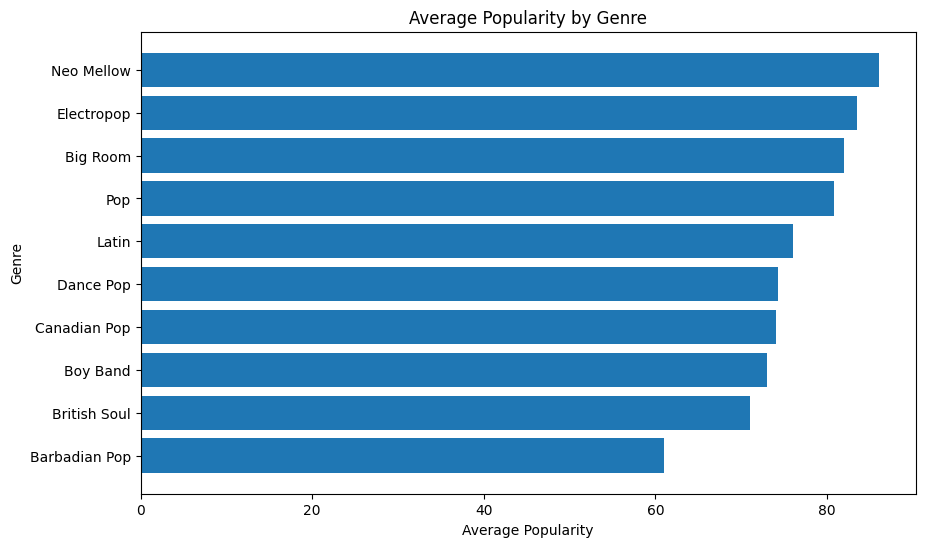

In [5]:
#Analyzing Popularity by Genre
#Using Pandas groupby to calculate average popularity and average streams by genre
genre_summary = (
    df.groupby('genre')
    .agg(
        avg_popularity=('popularity', 'mean'),
        avg_streams_millions=('streams_millions', 'mean'),
        song_count=('song', 'count')
    )
    .reset_index()
    .sort_values('avg_popularity', ascending=False)
)

top_genres = genre_summary.head(10)

#Display the Pandas table
display(top_genres)

#Create a bar chart of average popularity by genre
plt.figure(figsize=(10,6))
plt.barh(top_genres['genre'], top_genres['avg_popularity'])
plt.gca().invert_yaxis()
plt.title('Average Popularity by Genre')
plt.xlabel('Average Popularity')
plt.ylabel('Genre')
plt.show()


Genre Popularity Analysis

The chart above shows that some genres have higher average popularity than others. However, the `song_count` column is important because a genre with only one or two songs can have a high average if those songs are very successful. This means genre popularity should be interpreted carefully, since small groups can be strongly affected by one major hit.


,year,total_streams_millions,avg_streams_millions,avg_popularity,song_count
0,2010,3813.368673,762.673735,70.400000,5
1,2011,2449.401710,1224.700855,77.000000,2
2,2012,2613.102645,653.275661,70.000000,4
3,2013,2575.257717,858.419239,74.666667,3
4,2014,4607.840509,1151.960127,73.000000,4
5,2015,3448.557513,689.711503,72.400000,5
6,2016,5727.845935,954.640989,74.166667,6
7,2017,4793.968185,958.793637,77.000000,5
8,2018,3780.717608,1260.239203,78.666667,3
9,2019,6717.126587,1679.281647,81.750000,4


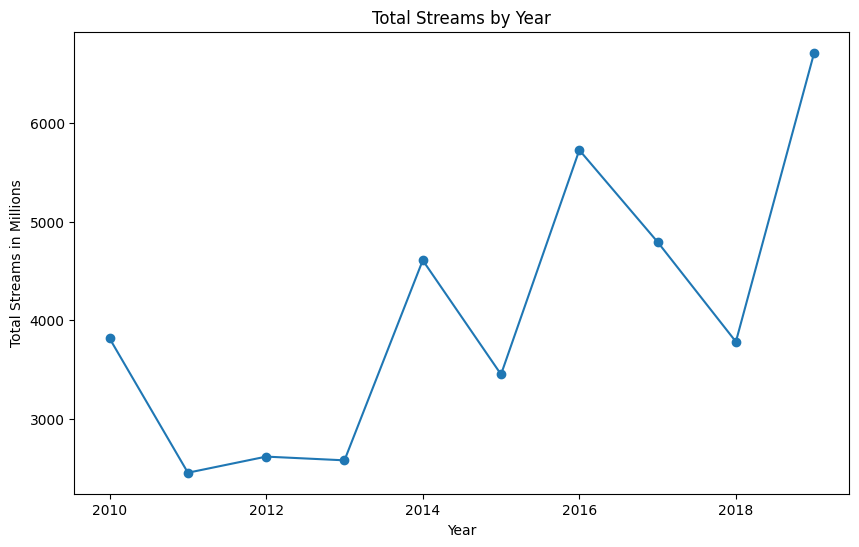

In [6]:
#Analyzing Streams by Year
#Grouping by year to see how total streams and average popularity change over time
year_summary = (
    df.groupby('year')
    .agg(
        total_streams_millions=('streams_millions', 'sum'),
        avg_streams_millions=('streams_millions', 'mean'),
        avg_popularity=('popularity', 'mean'),
        song_count=('song', 'count')
    )
    .reset_index()
    .sort_values('year')
)

#Display the Pandas table
display(year_summary)

#Create a line chart of total streams by year
plt.figure(figsize=(10,6))
plt.plot(year_summary['year'], year_summary['total_streams_millions'], marker='o')
plt.title('Total Streams by Year')
plt.xlabel('Year')
plt.ylabel('Total Streams in Millions')
plt.show()


Analysis of Streams by Year

The graph shows how total streams change across release years in the dataset. Some years have higher total streams because more major songs from those years are included. This shows that yearly streaming totals depend on both the number of songs in the dataset and the strength of the songs released in that year.


Correlation between Spotify playlists and streams: 0.985


,song,artist,in_spotify_playlists,streams_millions,popularity
10,All of Me,John Legend,33966,2420.461338,86
35,Closer,The Chainsmokers,33898,2355.719893,86
19,Beautiful People,Ed Sheeran,33206,2303.033973,86
14,Attention,Charlie Puth,22730,1791.000570,83
8,All Around The World (La La La),R3HAB,21106,1692.897992,82
2,A Thousand Years,Christina Perri,21097,1690.192927,81
29,Cake By The Ocean,DNCE,19806,1608.164312,81
31,Call You Mine,The Chainsmokers,18371,1575.467011,81
18,Bad Romance,Lady Gaga,15032,1406.111294,79
32,Cant Stop The Feeling,Justin Timberlake,14114,1304.313953,79


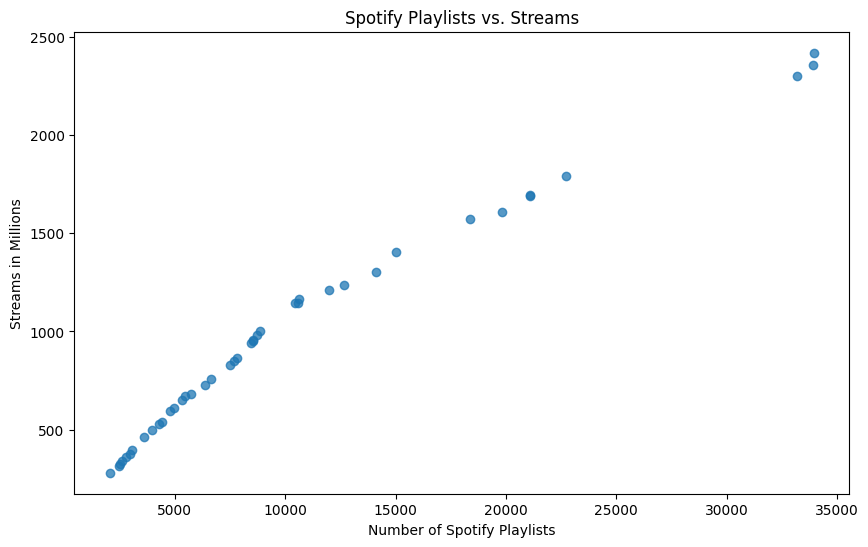

In [7]:
#Analyzing the Relationship Between Spotify Playlists and Streams
#Calculating the correlation between playlist placement and streams
playlist_stream_corr = df['in_spotify_playlists'].corr(df['streams_millions'])
print('Correlation between Spotify playlists and streams:', round(playlist_stream_corr, 3))

#Display songs with the most Spotify playlist placements
playlist_table = (
    df[['song', 'artist', 'in_spotify_playlists', 'streams_millions', 'popularity']]
    .sort_values('in_spotify_playlists', ascending=False)
    .head(10)
)

display(playlist_table)

#Create a scatter plot comparing playlists and streams
plt.figure(figsize=(10,6))
plt.scatter(df['in_spotify_playlists'], df['streams_millions'], alpha=0.75)
plt.title('Spotify Playlists vs. Streams')
plt.xlabel('Number of Spotify Playlists')
plt.ylabel('Streams in Millions')
plt.show()


Analysis of Spotify Playlist Placement and Streams

The scatter plot compares the number of Spotify playlists a song appears in with its total streams. Playlist placement matters because playlists can increase discovery and repeated listening. If the correlation is positive, that suggests songs in more playlists also tend to have more streams, supporting the idea that platform visibility is connected to streaming success.


,streams_millions,in_spotify_playlists,bpm,energy,danceability,liveness,valence,duration,acousticness,speechiness,popularity
streams_millions,1.00,0.98,-0.16,-0.37,-0.01,-0.09,-0.03,0.01,0.40,-0.13,0.83
in_spotify_playlists,0.98,1.00,-0.20,-0.39,-0.03,-0.13,-0.03,0.03,0.45,-0.11,0.77
bpm,-0.16,-0.20,1.00,0.03,-0.39,0.34,0.03,0.00,0.07,-0.09,-0.06
energy,-0.37,-0.39,0.03,1.00,-0.00,0.15,0.32,-0.25,-0.59,0.24,-0.27
danceability,-0.01,-0.03,-0.39,-0.00,1.00,-0.27,0.50,-0.29,-0.18,0.03,0.12
liveness,-0.09,-0.13,0.34,0.15,-0.27,1.00,-0.30,0.03,-0.13,-0.04,0.13
valence,-0.03,-0.03,0.03,0.32,0.50,-0.30,1.00,-0.33,-0.20,0.23,-0.05
duration,0.01,0.03,0.00,-0.25,-0.29,0.03,-0.33,1.00,0.23,-0.08,-0.03
acousticness,0.40,0.45,0.07,-0.59,-0.18,-0.13,-0.20,0.23,1.00,-0.23,0.22
speechiness,-0.13,-0.11,-0.09,0.24,0.03,-0.04,0.23,-0.08,-0.23,1.00,-0.08


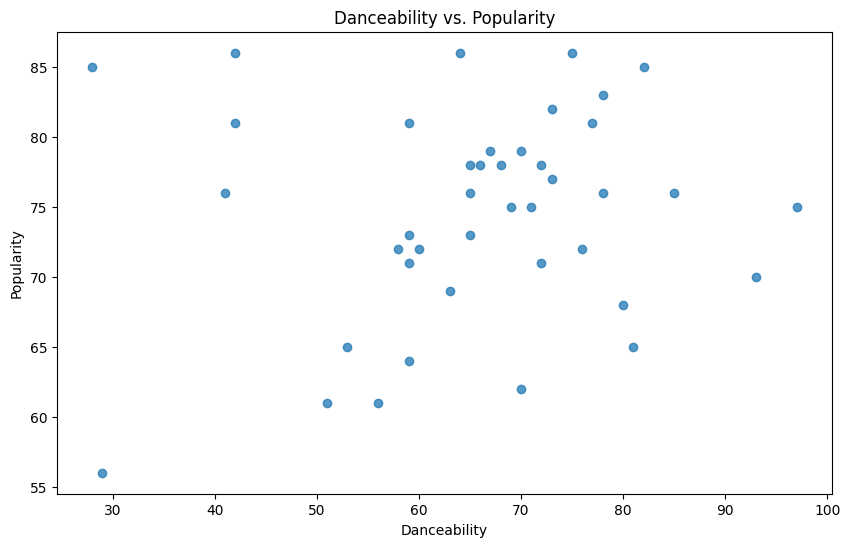

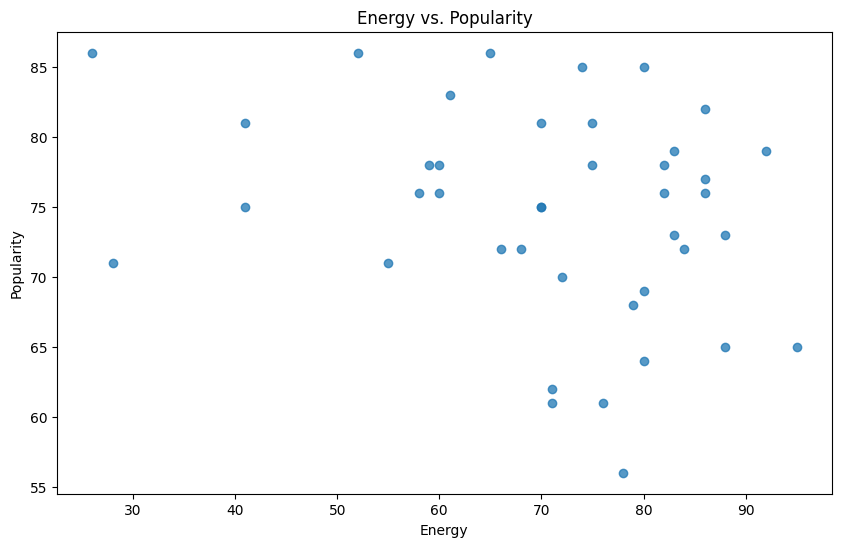

In [8]:
#Analyzing Audio Features and Popularity
#Calculating correlations between selected audio features and popularity
audio_features = [
    'streams_millions',
    'in_spotify_playlists',
    'bpm',
    'energy',
    'danceability',
    'liveness',
    'valence',
    'duration',
    'acousticness',
    'speechiness',
    'popularity'
]

correlation_table = df[audio_features].corr().round(2)
display(correlation_table)

#Scatter plot for danceability and popularity
plt.figure(figsize=(10,6))
plt.scatter(df['danceability'], df['popularity'], alpha=0.75)
plt.title('Danceability vs. Popularity')
plt.xlabel('Danceability')
plt.ylabel('Popularity')
plt.show()

#Scatter plot for energy and popularity
plt.figure(figsize=(10,6))
plt.scatter(df['energy'], df['popularity'], alpha=0.75)
plt.title('Energy vs. Popularity')
plt.xlabel('Energy')
plt.ylabel('Popularity')
plt.show()


Analysis of the Correlation Between Audio Features and Popularity

The correlation table and scatter plots show that audio features help describe songs, but they do not fully explain popularity by themselves. Danceability and energy can be useful for understanding the style of a song, but a song can still become popular even if it is not the most danceable or highest-energy track. This supports the idea that Spotify success comes from a mix of sound, playlist exposure, artist recognition, and replay value.


My Final Insights and Conclusion

Through my analysis of the Spotify songs dataset, several key patterns emerged relating to the six questions I initially proposed:

Top Songs: The most-streamed songs show that Spotify success can last across multiple years. A song does not have to be the newest release to remain highly streamed.

Artists: Artists with multiple popular songs have an advantage because total streams build across their catalog. This shows that artist recognition and consistency matter.

Genres: Some genres have higher average popularity, but genre results should be interpreted with song count. A small genre can rank highly if it contains one major hit.

Years: Stream totals change by year, but those totals depend on how many songs from each year are included and how successful those songs are.

Playlist Placement: Songs that appear in more Spotify playlists may have stronger streaming performance because playlists increase visibility and discovery.

Audio Features: Danceability and energy help describe a song's style, but they do not fully predict popularity. Overall, the data suggests that Spotify success is a combination of platform visibility, artist strength, replay value, and song characteristics.
